# Part 1: Real Life Examples and Simpson's Paradox

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import collections.abc

# Backward compatibility for causalgraphicalmodels (expects collections.Iterable)
if not hasattr(collections, "Iterable"):
    collections.Iterable = collections.abc.Iterable

from causalgraphicalmodels import CausalGraphicalModel
import statsmodels.api as sm
from scipy import stats
import os

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8')

# Create output directory if it doesn't exist
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## Part 1a: Real Life Examples (2 points)

### 1. Confounder

**Own Definition**: A confounder is a variable that influences both the explanatory variable (treatment) and the outcome variable, creating a false association between them if not accounted for.

**Economic Example**: The Returns to Education Problem

- **Education (X)**: Years of formal schooling completed (explanatory variable)
- **Earnings (Y)**: Annual wage income (outcome variable)
- **Ability (Z)**: Innate cognitive ability/intelligence (confounder)

**Graph**:

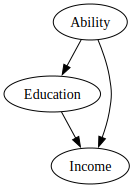

In [3]:
# Create and visualize confounder DAG
confounder_dag = CausalGraphicalModel(
    nodes=['Ability', 'Education', 'Income'],
    edges=[
        ('Ability', 'Education'),
        ('Ability', 'Income'),
        ('Education', 'Income')
    ]
)

# Draw and save the DAG
from graphviz import Source
dag_source = confounder_dag.draw()
dag_source.render(f'{output_dir}/confounder_dag', format='png', cleanup=True)
Source(dag_source.source)

### 2. Collider

**Own Definition**: A collider is a variable that is caused by both the explanatory variable and another variable, and conditioning on it can create spurious correlations.

**Economic Example**: The Beauty Premium in Academia

- **Research Productivity (X)**: Number of publications per year (explanatory variable)
- **Teaching Quality (Y)**: Student evaluation scores (outcome variable)
- **Academic Employment (Z)**: Being hired as a university professor (collider)

**Graph**:

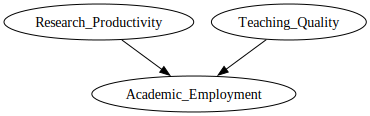

In [4]:
# Create and visualize collider DAG
collider_dag = CausalGraphicalModel(
    nodes=['Research_Productivity', 'Teaching_Quality', 'Academic_Employment'],
    edges=[
        ('Research_Productivity', 'Academic_Employment'),
        ('Teaching_Quality', 'Academic_Employment')
        # Note: No direct edge between Research_Productivity and Teaching_Quality
        # The spurious correlation only appears when we condition on Academic_Employment
    ]
)

# Draw and save the DAG
from graphviz import Source
dag_source = collider_dag.draw()
dag_source.render(f'{output_dir}/collider_dag', format='png', cleanup=True)
Source(dag_source.source)

### 3. Mediation

**Own Definition**: A mediator is a variable that transmits the effect from the explanatory variable to the outcome variable, lying on the causal pathway between them.

**Economic Example**: Minimum Wage Effects on Employment

- **Minimum Wage Policy (X)**: Legislative increase in minimum wage rates (explanatory variable)
- **Employment Level (Y)**: Regional employment rates (outcome variable)
- **Labor Costs (Z)**: Average cost per worker to employers (mediator)

**Graph**:

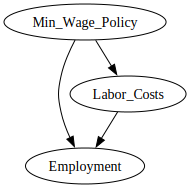

In [5]:
# Create and visualize mediation DAG
mediation_dag = CausalGraphicalModel(
    nodes=['Min_Wage_Policy', 'Labor_Costs', 'Employment'],
    edges=[
        ('Min_Wage_Policy', 'Labor_Costs'),
        ('Labor_Costs', 'Employment'),
        ('Min_Wage_Policy', 'Employment')  # Direct effect (efficiency wages, etc.)
    ]
)

# Draw and save the DAG
from graphviz import Source
dag_source = mediation_dag.draw()
dag_source.render(f'{output_dir}/mediation_dag', format='png', cleanup=True)
Source(dag_source.source)

## Part 1b: Simpson's Paradox (2 points)

**Explanation in my own words**: Simpson's paradox is when the relationship between two variables appears to be one way in separate subgroups but reverses when the data from all subgroups is combined. This happens due to confounding factors that differ between groups.

The simulation meets the criteria:
- Two groups: High-skill and low-skill workers
- Within each group: Positive slope between training hours (explanatory) and productivity (outcome)
- Combined: Negative slope overall

**Plot**: All observations are plotted in a single graph below, with three regression lines: one for each group and one for the pooled sample.

In [6]:
# Simulate Simpson's Paradox data
n_per_group = 200

# Group 1: High-skill workers
# X (training hours) and Y (productivity) have positive relationship
X1 = np.random.normal(8, 1, n_per_group)  # More training hours
Y1 = 20 + 2 * X1 + np.random.normal(0, 3, n_per_group)  # Lower base productivity
group1 = np.ones(n_per_group)

# Group 2: Low-skill workers  
# X (training hours) and Y (productivity) have positive relationship
X2 = np.random.normal(4, 1, n_per_group)  # Fewer training hours
Y2 = 50 + 2 * X2 + np.random.normal(0, 3, n_per_group)  # Higher base productivity
group2 = np.zeros(n_per_group)

# Combine groups
X_combined = np.concatenate([X1, X2])
Y_combined = np.concatenate([Y1, Y2])
groups = np.concatenate([group1, group2])

# Create DataFrame
df = pd.DataFrame({
    'training_hours': X_combined,
    'productivity': Y_combined,
    'skill_group': groups,
    'skill_label': ['High-skill' if g == 1 else 'Low-skill' for g in groups]
})

print("Data summary:")
print(df.groupby('skill_label')[['training_hours', 'productivity']].mean())

Data summary:
             training_hours  productivity
skill_label                              
High-skill         7.959229     36.176063
Low-skill          3.914345     57.855590


In [7]:
# Fit regression models
# Group 1 regression
X1_reg = sm.add_constant(df[df.skill_group == 1]['training_hours'])
model1 = sm.OLS(df[df.skill_group == 1]['productivity'], X1_reg).fit()

# Group 2 regression  
X2_reg = sm.add_constant(df[df.skill_group == 0]['training_hours'])
model2 = sm.OLS(df[df.skill_group == 0]['productivity'], X2_reg).fit()

# Combined regression
X_combined_reg = sm.add_constant(df['training_hours'])
model_combined = sm.OLS(df['productivity'], X_combined_reg).fit()

print(f"Group 1 (High-skill) slope: {model1.params[1]:.3f}")
print(f"Group 2 (Low-skill) slope: {model2.params[1]:.3f}")
print(f"Combined slope: {model_combined.params[1]:.3f}")
print(f"\nSimpsons paradox demonstrated: Individual groups show positive relationship ({model1.params[1]:.3f}, {model2.params[1]:.3f})")
print(f"but combined data shows negative relationship ({model_combined.params[1]:.3f})")

Group 1 (High-skill) slope: 2.303
Group 2 (Low-skill) slope: 2.326
Combined slope: -3.947

Simpsons paradox demonstrated: Individual groups show positive relationship (2.303, 2.326)
but combined data shows negative relationship (-3.947)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/2932159279.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Group 1 (High-skill) slope: {model1.params[1]:.3f}")
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/2932159279.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Group 2 (Low-skill) slope: {model2.params[1]:.3f}")
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/2932159279.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Da

/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/1555016404.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y1_pred = model1.params[0] + model1.params[1] * x_range
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/1555016404.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f'High-skill regression (slope: {model1.params[1]:.2f})')
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/1555016404.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with Dat

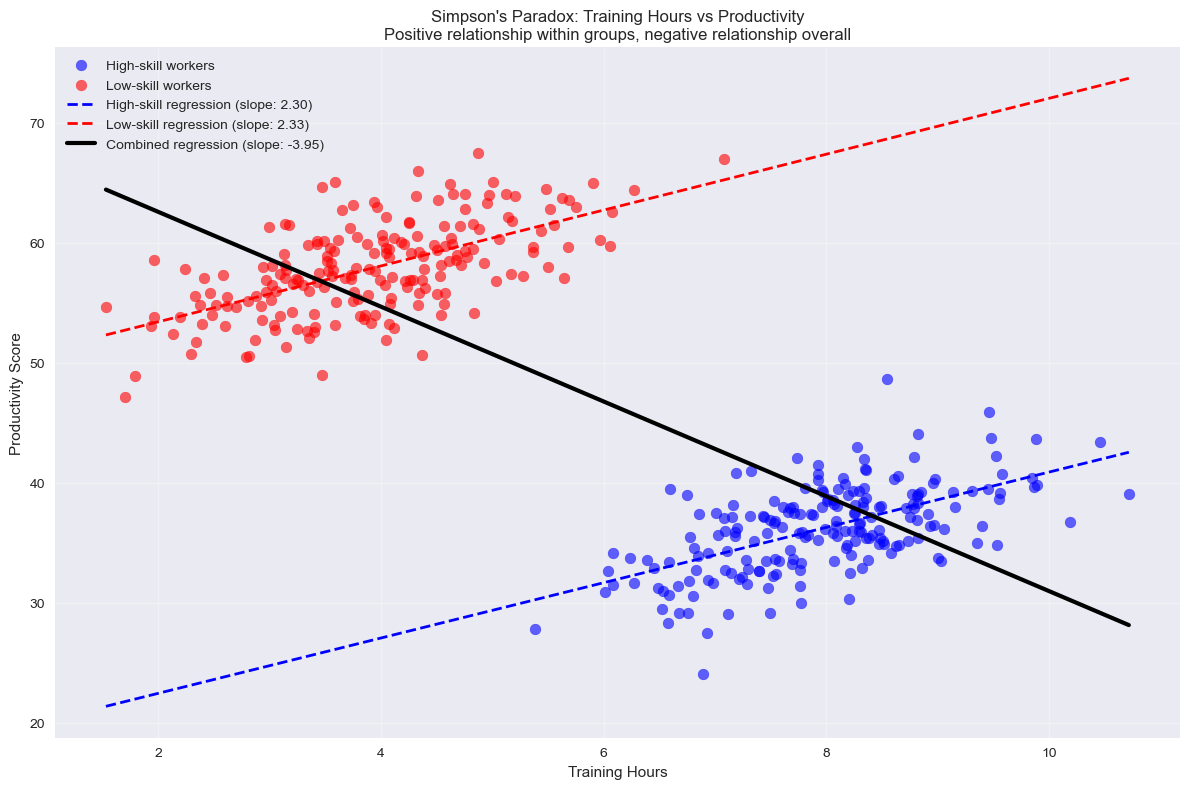

In [8]:
# Create the Simpson's Paradox plot
plt.figure(figsize=(12, 8))

# Plot data points by group
high_skill = df[df.skill_group == 1]
low_skill = df[df.skill_group == 0]

plt.scatter(high_skill['training_hours'], high_skill['productivity'], 
           alpha=0.6, c='blue', label='High-skill workers', s=60)
plt.scatter(low_skill['training_hours'], low_skill['productivity'], 
           alpha=0.6, c='red', label='Low-skill workers', s=60)

# Create regression lines
x_range = np.linspace(df['training_hours'].min(), df['training_hours'].max(), 100)

# Group 1 regression line
y1_pred = model1.params[0] + model1.params[1] * x_range
plt.plot(x_range, y1_pred, 'blue', linewidth=2, linestyle='--', 
         label=f'High-skill regression (slope: {model1.params[1]:.2f})')

# Group 2 regression line
y2_pred = model2.params[0] + model2.params[1] * x_range
plt.plot(x_range, y2_pred, 'red', linewidth=2, linestyle='--',
         label=f'Low-skill regression (slope: {model2.params[1]:.2f})')

# Combined regression line
y_combined_pred = model_combined.params[0] + model_combined.params[1] * x_range
plt.plot(x_range, y_combined_pred, 'black', linewidth=3, 
         label=f'Combined regression (slope: {model_combined.params[1]:.2f})')

plt.xlabel('Training Hours')
plt.ylabel('Productivity Score')
plt.title("Simpson's Paradox: Training Hours vs Productivity\n" +
          "Positive relationship within groups, negative relationship overall")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/simpsons_paradox.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Save simulation results
df.to_csv(f'{output_dir}/simpsons_paradox_data.csv', index=False)

# Save regression results
results_summary = pd.DataFrame({
    'Model': ['High-skill Group', 'Low-skill Group', 'Combined'],
    'Slope': [model1.params[1], model2.params[1], model_combined.params[1]],
    'Intercept': [model1.params[0], model2.params[0], model_combined.params[0]],
    'R_squared': [model1.rsquared, model2.rsquared, model_combined.rsquared]
})

results_summary.to_csv(f'{output_dir}/simpsons_paradox_results.csv', index=False)
print("\nRegression Results Summary:")
print(results_summary)


Regression Results Summary:
              Model     Slope  Intercept  R_squared
0  High-skill Group  2.302609  17.849068   0.345955
1   Low-skill Group  2.326042  48.750659   0.366254
2          Combined -3.946958  70.448077   0.594469


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/69446210.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Slope': [model1.params[1], model2.params[1], model_combined.params[1]],
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_93917/69446210.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Intercept': [model1.params[0], model2.params[0], model_combined.params[0]],


### Interpretation and Economic Implications

**What the Simulation Demonstrates**:

1. **Within-Group Relationships**: Both high-skill and low-skill workers show positive relationships between training hours and productivity:
   - High-skill group: slope = 2.30 (R² = 0.35)
   - Low-skill group: slope = 2.33 (R² = 0.37)
   These results suggest that training is effective for workers at all skill levels, with similar marginal effects.

2. **Simpson's Paradox**: When we ignore the skill-group distinction and pool all workers together, the relationship between training and productivity appears strongly negative (slope = -3.95, R² = 0.59). This creates the false impression that training reduces productivity!

3. **The Confounding Mechanism**: Skill level acts as a confounder because:
   - High-skill workers receive more training hours (selection effect)
   - High-skill workers have lower baseline productivity (intercept: 17.85 vs 48.75 for low-skill workers)
   - This creates a spurious negative correlation in the pooled data (slope = -3.95)

**Policy Implications**:

- **Misleading Aggregate Analysis**: A policymaker looking only at the pooled data would conclude that job training programs are highly counterproductive (with a large negative effect of -3.95) and should be eliminated.

- **Importance of Stratification**: Proper analysis by skill group reveals that training is actually beneficial for all workers with approximately equal effectiveness (+2.30 and +2.33), but the benefits must be evaluated within appropriate comparison groups.

- **Selection Bias**: The paradox highlights how program evaluation can be severely misleading when participants self-select or are selected based on characteristics that also affect outcomes. The high R² (0.59) in the combined model gives false confidence in the wrong conclusion.

**Statistical Lesson**: Simpson's Paradox demonstrates why correlation is not causation and emphasizes the critical importance of identifying and controlling for confounding variables in economic analysis. The reversal from strongly negative (-3.95) to positive (+2.3) effects shows how dramatic these errors can be.

**Real-World Applications**: Similar paradoxes appear in:
- Gender wage gap analysis (occupation as confounder)
- Education policy evaluation (socioeconomic status as confounder)  
- Medical treatment effectiveness (severity of condition as confounder)
- Regional economic development (initial development level as confounder)